# Decentralized Online Riemannian Optimization on Hadamard Manifolds

Experiments for **D-ROGD** (decentralized Riemannian online gradient descent) under
horospherical convexity, evaluated on a real concept hierarchy embedded in
hyperbolic space.

Each agent takes a local Riemannian gradient step followed by a consensus step given
by the weighted Frechet mean of its neighbours' iterates. Because the curvature of
hyperbolic space is a free parameter, we can hold the intrinsic scale of the data
fixed and vary curvature alone, which isolates the curvature dependence of the regret.

**Pipeline**

1. Extract a sub-hierarchy of the WordNet noun taxonomy and compute its tree metric.
2. Embed the tree metric into a Poincare ball by stress minimisation.
3. For each curvature, rescale the embedding so the intrinsic geodesic diameter is fixed.
4. Run D-ROGD on two objectives: geometric median (h-convex) and Frechet mean
   (strongly h-convex).
5. Sweep curvature, and separately sweep network topology.

Runtime is roughly 30-60 min on a single Kaggle GPU session; the online loop itself
runs on CPU (the tensors are tiny), the GPU only accelerates the embedding step.

In [1]:
!pip -q install geoopt nltk scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.7 MB/s eta 0:00:00


## Configuration

`KAPPAS` holds the curvature levels used in the experiments. `KAPPAS_PROBED` is a
wider set that includes two values which turn out to be infeasible; the feasibility
check below documents why they are excluded.

In [2]:
import numpy as np, torch, geoopt, nltk, matplotlib.pyplot as plt
from collections import deque
from sklearn.cluster import KMeans

torch.set_default_dtype(torch.float64)
DEV_EMB = 'cuda' if torch.cuda.is_available() else 'cpu'   # GPU only for the embedding
DEV     = 'cpu'                                            # online loop: tiny tensors

ROOT     = 'mammal.n.01'   # root synset of the WordNet sub-hierarchy
N_MAX    = 300             # maximum number of concepts
DIM      = 10              # dimension of the hyperbolic embedding
N_AGENTS = 8               # number of agents in the network
T        = 2000            # number of online rounds
SEEDS    = 3               # independent repetitions (averaged)
D_DIAM   = 4.0             # intrinsic geodesic diameter, held fixed across curvatures
NOISE    = 0.05            # geodesic magnitude of the observation perturbation

# Curvature levels -kappa. sqrt(kappa) * D_DIAM is the dimensionless
# curvature-diameter product, here 2, 4, 8, 12, 16.
KAPPAS        = [0.25, 1.0, 4.0, 9.0, 16.0]
KAPPAS_PROBED = KAPPAS + [25.0, 36.0]      # 25 and 36 fail the feasibility check

np.random.seed(0); torch.manual_seed(0)

## Data: WordNet sub-hierarchy and its hyperbolic embedding

We take the sub-hierarchy rooted at `mammal.n.01`, following hyponymy (is-a) edges by
breadth-first search. Only the first parent edge of each synset is kept, so the WordNet
DAG is reduced to a tree. All-pairs shortest-path distances on that tree give the target
metric, which is embedded into the unit-curvature Poincare ball by minimising stress.

A k-means partition of the embedding assigns each agent a semantically coherent cluster
of concepts, which makes the local objectives systematically heterogeneous rather than
merely noisy.

In [3]:
nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet as wn


def get_subtree(root_name, n_max):
    """Breadth-first extraction of a hyponymy sub-tree (first parent edge only)."""
    root = wn.synset(root_name); idx = {root: 0}; nodes = [root]; edges = []
    q = deque([root])
    while q and len(nodes) < n_max:
        s = q.popleft()
        for c in s.hyponyms():
            if c not in idx and len(nodes) < n_max:
                idx[c] = len(nodes); nodes.append(c)
                edges.append((idx[s], idx[c])); q.append(c)
    return nodes, edges


def all_pairs_tree_dist(N, edges):
    """All-pairs shortest-path (hop) distances on the tree."""
    adj = [[] for _ in range(N)]
    for a, b in edges:
        adj[a].append(b); adj[b].append(a)
    G = np.zeros((N, N))
    for src in range(N):
        dist = [-1]*N; dist[src] = 0; q = deque([src])
        while q:
            u = q.popleft()
            for v in adj[u]:
                if dist[v] < 0:
                    dist[v] = dist[u] + 1; q.append(v)
        G[src] = [d if d >= 0 else N for d in dist]
    return G


nodes, edges = get_subtree(ROOT, N_MAX)
N = len(nodes)
G = all_pairs_tree_dist(N, edges)

# Stress embedding into the unit-curvature Poincare ball.
ball1  = geoopt.PoincareBall(c=1.0)
target = (torch.tensor(G) * (3.0 / G.max())).to(DEV_EMB)    # normalised target metric
mask   = torch.triu(torch.ones(N, N), 1).bool().to(DEV_EMB)
X0     = geoopt.ManifoldParameter(
             ball1.projx(torch.randn(N, DIM, device=DEV_EMB) * 1e-2), manifold=ball1)
opt    = geoopt.optim.RiemannianAdam([X0], lr=5e-3)
for _ in range(800):
    opt.zero_grad()
    A  = X0[:, None, :].expand(N, N, DIM).reshape(N*N, DIM)
    B  = X0[None, :, :].expand(N, N, DIM).reshape(N*N, DIM)
    Dh = ball1.dist(A, B).reshape(N, N)
    loss = ((Dh - target)[mask] ** 2).mean()
    loss.backward(); opt.step()
U = X0.detach().to(DEV)          # unit-curvature coordinates: the "shape" of the data

# Assign each agent one semantic cluster of concepts.
labels   = KMeans(n_clusters=N_AGENTS, n_init=10, random_state=0).fit_predict(U.cpu().numpy())
clusters = [np.where(labels == i)[0] for i in range(N_AGENTS)]
clusters = [c if len(c) else np.array([np.random.randint(N)]) for c in clusters]

print(f"{N} WordNet concepts under '{ROOT}'; embedding stress = {loss.item():.3f}")

300 WordNet concepts under 'mammal.n.01'; embedding stress = 0.161


## Geometry, algorithm and communication graphs

`run_droged` implements one full run of D-ROGD. In each round every agent first incurs
the global loss at its current iterate (regret accounting, before any update), then
takes a local gradient step using only its own observation, projects back onto the
feasible set, and finally performs the consensus step.

Two points worth noting:

* The consensus step is a weighted Frechet mean, which has no closed form on a general
  manifold. It is solved by a Karcher fixed-point iteration run to a convergence
  tolerance rather than for a fixed number of steps, because the contraction rate of
  that iteration itself depends on curvature; a fixed step budget would therefore solve
  the sub-problem less accurately at higher curvature and bias exactly the quantity
  being measured.
* `perturb` applies a perturbation of fixed *geodesic* magnitude. A tangent vector of
  fixed Euclidean coordinate norm has intrinsic norm scaled by the conformal factor
  `lambda_x = 2 / (1 - c |x|^2)`, which grows with both the radius of the point and the
  curvature. Perturbing with raw coordinate noise would therefore make the observation
  noise grow with curvature and confound the curvature comparison.

In [4]:
def dist_matrix(ball, A, B):
    n, d = A.shape; m = B.shape[0]
    Ae = A[:, None, :].expand(n, m, d).reshape(n*m, d)
    Be = B[None, :, :].expand(n, m, d).reshape(n*m, d)
    return ball.dist(Ae, Be).reshape(n, m)


def loss_mat(ball, A, B, task):
    dm = dist_matrix(ball, A, B)
    return 0.5 * dm**2 if task == 'frechet' else dm


def proj_radius(ball, P, R):
    """Project onto the geodesic ball of radius R centred at the origin."""
    o = torch.zeros_like(P)
    d = ball.dist(o, P).clamp_min(1e-12)
    u = ball.logmap(o, P)
    return ball.expmap(o, u * torch.clamp(R/d, max=1.0)[:, None])


def clip_tangent(v, max_norm):
    nv = v.norm(dim=-1, keepdim=True).clamp_min(1e-12)
    return v * torch.clamp(torch.as_tensor(float(max_norm)) / nv, max=1.0)


def consensus_step(ball, Y, W, max_iter=60, tol=1e-9):
    """Weighted Frechet mean by Karcher fixed-point iteration, run to tolerance."""
    n, d = Y.shape; Z = Y.clone()
    for _ in range(max_iter):
        Ze = Z[:, None, :].expand(n, n, d).reshape(n*n, d)
        Ye = Y[None, :, :].expand(n, n, d).reshape(n*n, d)
        logs = ball.logmap(Ze, Ye).reshape(n, n, d)
        update = (W[:, :, None] * logs).sum(1)
        Z = ball.expmap(Z, update)
        if update.norm(dim=-1).max().item() < tol:
            break
    return Z


def fixed_iter_consensus(ball, Y, W, n_iter):
    """Fixed-budget variant, used only by the ablation below."""
    n, d = Y.shape; Z = Y.clone()
    for _ in range(n_iter):
        Ze = Z[:, None, :].expand(n, n, d).reshape(n*n, d)
        Ye = Y[None, :, :].expand(n, n, d).reshape(n*n, d)
        logs = ball.logmap(Ze, Ye).reshape(n, n, d)
        Z = ball.expmap(Z, (W[:, :, None] * logs).sum(1))
    return Z


def perturb(ball, P, sigma, xi):
    """Perturbation of geodesic magnitude sigma * |xi|, independent of position
       and curvature. Uses |u|_P = lambda_P |u|_E with lambda_P = 2/(1 - c|P|^2)."""
    c   = float(ball.c)
    lam = 2.0 / (1.0 - c * (P * P).sum(-1, keepdim=True))
    return ball.expmap(P, sigma * xi / lam)


def base_for_kappa(U, kappa, D, cap=1 - 1e-8, verbose=False):
    """Rescale the embedding radially in the kappa-ball so its intrinsic diameter is D.
       Returns the manifold and the point cloud; warns if the diameter is not attained."""
    ball = geoopt.PoincareBall(c=kappa)
    rmax = U.norm(dim=1).max().item()
    lo, hi = 1e-12, cap / (np.sqrt(kappa) * rmax)
    for _ in range(200):
        s = 0.5 * (lo + hi)
        if dist_matrix(ball, ball.projx(s*U), ball.projx(s*U)).max().item() < D:
            lo = s
        else:
            hi = s
    P = ball.projx(0.5 * (lo + hi) * U)
    D_ach   = dist_matrix(ball, P, P).max().item()
    lam_max = (2.0 / (1.0 - kappa * (P*P).sum(-1))).max().item()
    if verbose:
        print(f"  kappa={kappa:7.3f}  attained D={D_ach:.4f} (target {D})  "
              f"max lambda={lam_max:.4g}  sqrt(kappa)*D={np.sqrt(kappa)*D_ach:.2f}")
    if abs(D_ach - D) > 0.02 * D:
        print(f"  WARNING kappa={kappa}: target diameter not attained, exclude "
              f"this curvature from the sweep")
    return ball, P


def batch_optimum(ball, P, task, R, epochs=400, eta0=1.0, mu=1.0):
    """Offline comparator x* = argmin_{x in X} sum_j loss(x, P_j), by projected
       Riemannian gradient descent on the full batch, constrained to X."""
    m, d = P.shape
    z = proj_radius(ball, ball.projx(P.mean(0, keepdim=True)), R)
    for k in range(epochs):
        logs = ball.logmap(z.expand(m, d), P)
        if task == 'frechet':
            g = -logs.mean(0, keepdim=True); eta = 1.0 / (mu * (k + 1))
        else:
            dd = ball.dist(z.expand(m, d), P).clamp_min(1e-9)
            g = -(logs / dd[:, None]).mean(0, keepdim=True); eta = eta0 / np.sqrt(k + 1)
        z = proj_radius(ball, ball.expmap(z, clip_tangent(-eta*g, 0.5*R)), R)
    return z.detach().squeeze(0)


def run_droged(ball, Zstream, W, task, xstar, R, eta0, mu=1.0,
               step_cap=None, consensus_fn=None):
    """One run of D-ROGD; returns the cumulative network regret per round."""
    if consensus_fn is None:
        consensus_fn = lambda Y: consensus_step(ball, Y, W)
    T_, n, d = Zstream.shape
    X   = torch.zeros(n, d)
    reg = torch.zeros(T_)
    cap = step_cap if step_cap is not None else 0.5 * R
    for t in range(T_):
        Zt = Zstream[t]
        # incur the global loss at the current iterates, before any update
        reg[t] = loss_mat(ball, X, Zt, task).mean(1).mean() \
                 - loss_mat(ball, xstar.unsqueeze(0), Zt, task).mean()
        logs = ball.logmap(X, Zt)                     # own observation only
        if task == 'frechet':
            g = -logs; eta = 1.0 / (mu * (t + 1))
        else:
            dd = ball.dist(X, Zt).clamp_min(1e-9)
            g = -logs / dd[:, None]; eta = eta0 / np.sqrt(t + 1)
        Y = proj_radius(ball, ball.expmap(X, clip_tangent(-eta*g, cap)), R)
        X = consensus_fn(Y)
    return reg.cumsum(0)


# ---- communication graphs and Metropolis weights (symmetric, doubly stochastic) ----
def metropolis(A):
    n = A.shape[0]; deg = A.sum(1); W = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if A[i, j] > 0:
                W[i, j] = 1 / (1 + max(deg[i], deg[j]))
        W[i, i] = 1 - W[i].sum()
    return W


def ring_adj(n):
    A = np.zeros((n, n))
    for i in range(n):
        A[i, (i+1) % n] = A[(i+1) % n, i] = 1
    return A


def path_adj(n):
    A = np.zeros((n, n))
    for i in range(n-1):
        A[i, i+1] = A[i+1, i] = 1
    return A


def er_adj(n, p, seed):
    """Erdos-Renyi G(n, p); isolated nodes are connected to keep the graph connected."""
    rng = np.random.default_rng(seed); A = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            if rng.random() < p:
                A[i, j] = A[j, i] = 1
    for i in range(n):
        if A[i].sum() == 0:
            j = (i+1) % n; A[i, j] = A[j, i] = 1
    return A


def sigma2(W):
    """Second largest singular value of W."""
    return np.linalg.svd(W)[1][1]

## Feasibility of the curvature sweep

Holding the intrinsic diameter at `D = 4` while increasing curvature pushes the point
cloud towards the boundary of the Poincare ball, where the float64 representation runs
out of resolution. This check reports the diameter actually attained at each curvature.
Values for which the target is not met are excluded from all experiments; with the
present configuration this happens for `kappa = 25` and `kappa = 36`, which is why
`KAPPAS` stops at 16.

In [5]:
print("Attained intrinsic diameter per curvature level:")
for kappa in KAPPAS_PROBED:
    base_for_kappa(U, kappa, D_DIAM, verbose=True)

Attained intrinsic diameter per curvature level:
  kappa=  0.250  attained D=4.0000 (target 4.0)  max lambda=2.611  sqrt(kappa)*D=2.00
  kappa=  1.000  attained D=4.0000 (target 4.0)  max lambda=5.129  sqrt(kappa)*D=4.00
  kappa=  4.000  attained D=4.0000 (target 4.0)  max lambda=33.26  sqrt(kappa)*D=8.00
  kappa=  9.000  attained D=4.0000 (target 4.0)  max lambda=281.2  sqrt(kappa)*D=12.00
  kappa= 16.000  attained D=4.0000 (target 4.0)  max lambda=5328  sqrt(kappa)*D=16.00
  kappa= 25.000  attained D=3.3622 (target 4.0)  max lambda=1e+05  sqrt(kappa)*D=16.81
  WARNING kappa=25.0: target diameter not attained, exclude this curvature from the sweep
  kappa= 36.000  attained D=2.8019 (target 4.0)  max lambda=1e+05  sqrt(kappa)*D=16.81
  WARNING kappa=36.0: target diameter not attained, exclude this curvature from the sweep


## Validation of the intrinsic perturbation

Confirms that `perturb` produces a displacement of the intended geodesic magnitude at
every curvature, and shows for comparison what raw coordinate noise of the same nominal
size would produce.

In [6]:
print(f"{'sqrt(k)D':>9} {'max lambda':>11} {'target':>9} {'intrinsic':>10} {'raw coords':>11}")
for kappa in KAPPAS:
    ball, base = base_for_kappa(U, kappa, D_DIAM)
    xi   = torch.randn(base.shape[0], DIM, generator=torch.Generator().manual_seed(0))
    lam  = 2.0 / (1.0 - float(ball.c) * (base*base).sum(-1, keepdim=True))
    d_int = ball.dist(base, perturb(ball, base, NOISE, xi)).mean().item()
    d_raw = ball.dist(base, ball.expmap(base, NOISE * xi)).mean().item()
    print(f"{np.sqrt(kappa)*D_DIAM:9.1f} {lam.max().item():11.4g} "
          f"{(NOISE*xi.norm(dim=-1)).mean().item():9.4f} {d_int:10.4f} {d_raw:11.4f}")

 sqrt(k)D  max lambda    target  intrinsic  raw coords
      2.0       2.611    0.1542     0.1542      0.3570
      4.0       5.129    0.1542     0.1542      0.4920
      8.0       33.26    0.1542     0.1542      0.8612
     12.0       281.2    0.1542     0.1542      0.8845
     16.0        5328    0.1542     0.1542      0.8667


## Main curvature sweep

The observation stream (which concept each agent draws in each round, and the noise
realisations) is generated once and reused across curvature levels, so that curvature
is the only quantity that changes.

Objectives: the geometric median `d(x, Z)` is h-convex and uses `eta_t = 1/sqrt(t)`;
the Frechet mean `0.5 d(x, Z)^2` is 1-strongly h-convex and uses `eta_t = 1/(mu t)`.

In [7]:
streams = []
for s in range(SEEDS):
    rng = np.random.default_rng(100 + s)
    tg  = torch.Generator().manual_seed(100 + s)
    idx = np.stack([rng.choice(clusters[i], size=T) for i in range(N_AGENTS)], axis=1)
    streams.append((torch.tensor(idx), torch.randn(T, N_AGENTS, DIM, generator=tg)))

W_ring  = torch.tensor(metropolis(ring_adj(N_AGENTS)))
results = {}

for task in ['median', 'frechet']:
    for kappa in KAPPAS:
        ball, base = base_for_kappa(U, kappa, D_DIAM)
        R   = 1.2 * dist_matrix(ball, torch.zeros(1, DIM), base).max().item()
        acc = torch.zeros(T)
        for s in range(SEEDS):
            idx, noise = streams[s]
            Zb      = base[idx.reshape(-1)].reshape(T, N_AGENTS, DIM)
            Zstream = perturb(ball, Zb, NOISE, noise)
            xstar   = batch_optimum(ball, Zstream.reshape(T*N_AGENTS, DIM), task, R)
            acc    += run_droged(ball, Zstream, W_ring, task, xstar, R, eta0=1.0)
        reg = acc / SEEDS
        results[(task, kappa)] = reg.numpy()
        # regret must be non-negative in expectation; a negative value indicates
        # that the comparator solver has not converged
        if reg[-1] < -0.02 * max(1.0, reg.abs().max().item()):
            print(f"  WARNING negative regret at kappa={kappa}; increase "
                  f"batch_optimum epochs")
        print(f"[{task:7s}] sqrt(k)D={np.sqrt(kappa)*D_DIAM:5.1f}  "
              f"Reg(T)={reg[-1]:7.2f}")

[median ] sqrt(k)D=  2.0  Reg(T)=   5.04
[median ] sqrt(k)D=  4.0  Reg(T)=   5.65
[median ] sqrt(k)D=  8.0  Reg(T)=   6.69
[median ] sqrt(k)D= 12.0  Reg(T)=   7.71
[median ] sqrt(k)D= 16.0  Reg(T)=   8.30
[frechet] sqrt(k)D=  2.0  Reg(T)=   1.70
[frechet] sqrt(k)D=  4.0  Reg(T)=   1.29
[frechet] sqrt(k)D=  8.0  Reg(T)=   0.67
[frechet] sqrt(k)D= 12.0  Reg(T)=   0.38
[frechet] sqrt(k)D= 16.0  Reg(T)=   0.25


## Ablation: accuracy of the consensus sub-problem

Regret is reported as a function of the number of Karcher iterations used for the
consensus step, at the smallest and largest curvature, together with the
tolerance-based solver used for the reported results. If the value plateaus and the
plateau agrees with the tolerance-based solver, the results do not depend on the
accuracy of this sub-problem.

In [8]:
def consensus_ablation(kappa, task='median', n_iters=(1, 2, 3, 5, 8, 12, 20, 40)):
    ball, base = base_for_kappa(U, kappa, D_DIAM)
    R = 1.2 * dist_matrix(ball, torch.zeros(1, DIM), base).max().item()
    idx, noise = streams[0]
    Zstream = perturb(ball, base[idx.reshape(-1)].reshape(T, N_AGENTS, DIM), NOISE, noise)
    xstar   = batch_optimum(ball, Zstream.reshape(T*N_AGENTS, DIM), task, R)
    norm    = np.sqrt(T) if task == 'median' else np.log(T)
    print(f"kappa={kappa}  (sqrt(k)D={np.sqrt(kappa)*D_DIAM:.1f})")
    for n_iter in n_iters:
        cfn = lambda Y, ni=n_iter: fixed_iter_consensus(ball, Y, W_ring, ni)
        reg = run_droged(ball, Zstream, W_ring, task, xstar, R, eta0=1.0, consensus_fn=cfn)
        print(f"  {n_iter:3d} iterations       Reg(T)/norm = {reg[-1].item()/norm:.4f}")
    reg = run_droged(ball, Zstream, W_ring, task, xstar, R, eta0=1.0)
    print(f"  tolerance-based     Reg(T)/norm = {reg[-1].item()/norm:.4f}")


for kappa in [min(KAPPAS), max(KAPPAS)]:
    consensus_ablation(kappa)

kappa=0.25  (sqrt(k)D=2.0)
    1 iterations       Reg(T)/norm = 0.1143
    2 iterations       Reg(T)/norm = 0.1144
    3 iterations       Reg(T)/norm = 0.1144
    5 iterations       Reg(T)/norm = 0.1144
    8 iterations       Reg(T)/norm = 0.1144
   12 iterations       Reg(T)/norm = 0.1144
   20 iterations       Reg(T)/norm = 0.1144
   40 iterations       Reg(T)/norm = 0.1144
  tolerance-based     Reg(T)/norm = 0.1144
kappa=16.0  (sqrt(k)D=16.0)
    1 iterations       Reg(T)/norm = 0.1741
    2 iterations       Reg(T)/norm = 0.1789
    3 iterations       Reg(T)/norm = 0.1763
    5 iterations       Reg(T)/norm = 0.1757
    8 iterations       Reg(T)/norm = 0.1761
   12 iterations       Reg(T)/norm = 0.1767
   20 iterations       Reg(T)/norm = 0.1758
   40 iterations       Reg(T)/norm = 0.1829
  tolerance-based     Reg(T)/norm = 0.1829


## Network connectivity

The regret bound depends on the network only through the inverse spectral gap
`sigma_2(W) / (1 - sigma_2(W))`. Four topologies span the range of `sigma_2`: the
complete graph gives exact averaging in one step (`sigma_2 = 0`), while the path graph
is the least connected. The sweep is repeated at two curvature levels.

In [9]:
topos = {'complete': np.ones((N_AGENTS, N_AGENTS)) - np.eye(N_AGENTS),
         'ER(p=0.5)': er_adj(N_AGENTS, 0.5, 1),
         'ring': ring_adj(N_AGENTS),
         'path': path_adj(N_AGENTS)}

sg_data = {}
for kappa in [1.0, 16.0]:
    ball, base = base_for_kappa(U, kappa, D_DIAM)
    R = 1.2 * dist_matrix(ball, torch.zeros(1, DIM), base).max().item()
    xs, ys = [], []
    for name, A in topos.items():
        W = torch.tensor(metropolis(A)); acc = torch.zeros(T)
        for s in range(SEEDS):
            idx, noise = streams[s]
            Zstream = perturb(ball, base[idx.reshape(-1)].reshape(T, N_AGENTS, DIM),
                              NOISE, noise)
            xstar   = batch_optimum(ball, Zstream.reshape(T*N_AGENTS, DIM), 'median', R)
            acc    += run_droged(ball, Zstream, W, 'median', xstar, R, eta0=1.0)
        xs.append(sigma2(metropolis(A))); ys.append((acc / SEEDS)[-1].item())
        print(f"[kappa={kappa:4.1f}] {name:10s} sigma_2={xs[-1]:.3f}  Reg(T)={ys[-1]:6.2f}")
    sg_data[kappa] = (np.array(xs), np.array(ys))

[kappa= 1.0] complete   sigma_2=0.000  Reg(T)=  2.16
[kappa= 1.0] ER(p=0.5)  sigma_2=0.614  Reg(T)=  3.06
[kappa= 1.0] ring       sigma_2=0.805  Reg(T)=  5.65
[kappa= 1.0] path       sigma_2=0.949  Reg(T)= 13.19
[kappa=16.0] complete   sigma_2=0.000  Reg(T)=  2.95
[kappa=16.0] ER(p=0.5)  sigma_2=0.614  Reg(T)=  4.65
[kappa=16.0] ring       sigma_2=0.805  Reg(T)=  8.30
[kappa=16.0] path       sigma_2=0.949  Reg(T)= 13.52


## Save raw results

Writes the arrays behind every figure, so the figures can be regenerated without
rerunning the experiments. On Kaggle these land in `/kaggle/working` and appear under
the **Output** tab of the saved version.

In [10]:
import json, os

np.savez('raw_curvature.npz',
         kappas=np.array(KAPPAS),
         sqkD=np.array([np.sqrt(k)*D_DIAM for k in KAPPAS]),
         reg_median=np.stack([results[('median', k)] for k in KAPPAS]),
         reg_frechet=np.stack([results[('frechet', k)] for k in KAPPAS]))

np.savez('raw_spectral.npz',
         sigma2=sg_data[1.0][0], reg_k1=sg_data[1.0][1], reg_k16=sg_data[16.0][1])

np.save('embedding_U.npy', U.cpu().numpy())
np.save('cluster_labels.npy', labels)

json.dump(dict(T=T, DIM=DIM, N_AGENTS=N_AGENTS, SEEDS=SEEDS, D_DIAM=D_DIAM,
               NOISE=NOISE, N=int(N), ROOT=ROOT, N_MAX=N_MAX, KAPPAS=KAPPAS),
          open('meta.json', 'w'), indent=2)

print("saved:", sorted(f for f in os.listdir('.')
                       if f.endswith(('.npz', '.npy', '.json'))))

saved: ['cluster_labels.npy', 'embedding_U.npy', 'meta.json', 'raw_curvature.npz', 'raw_spectral.npz']


## Figures

The two figures used in the paper. Both are generated at the same width so that their
font sizes match once scaled into the manuscript.

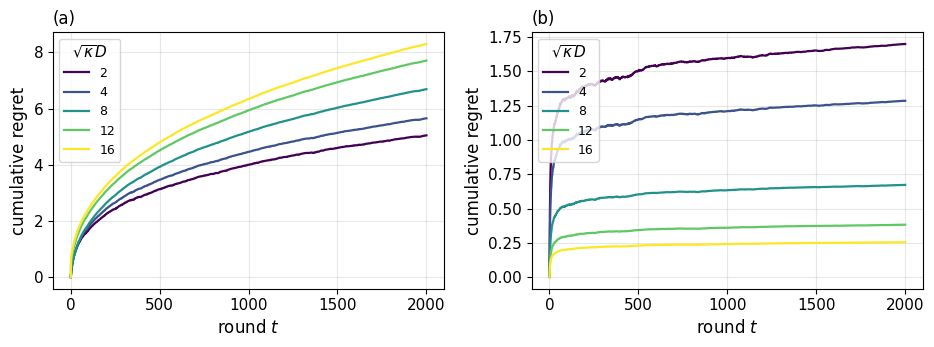

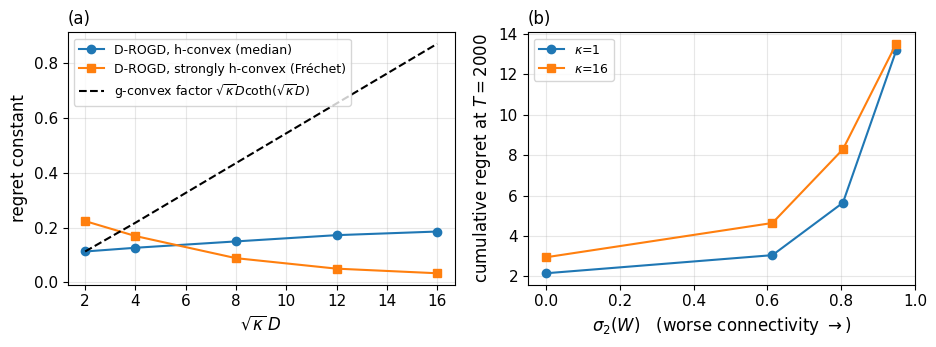

sqrt(k)D from 2 to 16:
  h-convex constant          0.113 -> 0.186  (x1.64)
  strongly h-convex constant 0.224 -> 0.033  (x0.15)
  g-convex factor zeta       2.07 -> 16.00  (x7.71)


In [11]:
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12,
                     'legend.fontsize': 9, 'axes.titlesize': 12})
FIGSIZE = (9.5, 3.6)

x     = np.array([np.sqrt(k) * D_DIAM for k in KAPPAS])
C_med = np.array([results[('median',  k)][-1] for k in KAPPAS]) / np.sqrt(T)
C_fre = np.array([results[('frechet', k)][-1] for k in KAPPAS]) / np.log(T)
zeta  = x * np.cosh(x) / np.sinh(x)

# ---- Figure 1: cumulative regret against t, one curve per curvature ----
tt   = np.arange(1, T + 1)
cmap = plt.cm.viridis(np.linspace(0, 1, len(KAPPAS)))
fig, ax = plt.subplots(1, 2, figsize=FIGSIZE)
for j, task in enumerate(['median', 'frechet']):
    for c, k, xv in zip(cmap, KAPPAS, x):
        ax[j].plot(tt, results[(task, k)], color=c, lw=1.6, label=f'{xv:.0f}')
    ax[j].set_title('(a)' if j == 0 else '(b)', loc='left')
    ax[j].set_xlabel('round $t$'); ax[j].set_ylabel('cumulative regret')
    ax[j].legend(title=r'$\sqrt{\kappa}D$'); ax[j].grid(alpha=.3)
plt.tight_layout(); plt.savefig('fig_regret_vs_T.pdf', bbox_inches='tight'); plt.show()

# ---- Figure 2: (a) regret constants against curvature, (b) against spectral gap ----
fig, ax = plt.subplots(1, 2, figsize=FIGSIZE)

ref = zeta / zeta[0] * C_med[0]      # scaled to start at the leftmost h-convex point
ax[0].plot(x, C_med, 'o-', label='D-ROGD, h-convex (median)')
ax[0].plot(x, C_fre, 's-', label='D-ROGD, strongly h-convex (Fréchet)')
ax[0].plot(x, ref, 'k--',
           label=r'g-convex factor $\sqrt{\kappa}D\coth(\sqrt{\kappa}D)$')
ax[0].set_xlabel(r'$\sqrt{\kappa}\,D$'); ax[0].set_ylabel('regret constant')
ax[0].set_title('(a)', loc='left'); ax[0].legend(); ax[0].grid(alpha=.3)

for kappa, mk in [(1.0, 'o'), (16.0, 's')]:
    xs, ys = sg_data[kappa]; o = np.argsort(xs)
    ax[1].plot(np.asarray(xs)[o], np.asarray(ys)[o], mk + '-',
               label=rf'$\kappa$={kappa:.0f}')
ax[1].set_xlim(-0.05, 1.0)
ax[1].set_xlabel(r'$\sigma_2(W)$   (worse connectivity $\rightarrow$)')
ax[1].set_ylabel(rf'cumulative regret at $T={T}$')
ax[1].set_title('(b)', loc='left'); ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.savefig('fig_curv_net.pdf', bbox_inches='tight'); plt.show()

print(f"sqrt(k)D from {x[0]:.0f} to {x[-1]:.0f}:")
print(f"  h-convex constant          {C_med[0]:.3f} -> {C_med[-1]:.3f}  "
      f"(x{C_med[-1]/C_med[0]:.2f})")
print(f"  strongly h-convex constant {C_fre[0]:.3f} -> {C_fre[-1]:.3f}  "
      f"(x{C_fre[-1]/C_fre[0]:.2f})")
print(f"  g-convex factor zeta       {zeta[0]:.2f} -> {zeta[-1]:.2f}  "
      f"(x{zeta[-1]/zeta[0]:.2f})")